In [14]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [16]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/gev_fit_scores_kmeans_gev_k3.csv")

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

# Keep only station + cluster label from the GEV table
label_df = GEV_clusters[["station", "cluster"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster']


Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())


Train size: (209, 187)  Test size: (70, 187)
Train class counts:
 cluster
1    102
0     91
2     16
Name: count, dtype: int64
Test class counts:
 cluster
1    34
0    31
2     5
Name: count, dtype: int64


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    multi_class="multinomial",
    max_iter=5000,
    C=1.0,
    random_state=0
)

logit_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logit),
])

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scoring = {"acc": "accuracy", "f1w": "f1_weighted"}

cv_res = cross_validate(logit_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("CV accuracy:", cv_res["test_acc"].mean(), "+/-", cv_res["test_acc"].std())
print("CV f1_weighted:", cv_res["test_f1w"].mean(), "+/-", cv_res["test_f1w"].std())
from sklearn.metrics import confusion_matrix, classification_report

logit_pipe.fit(X_train, y_train)
y_pred = logit_pipe.predict(X_test)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


CV accuracy: 0.7708478513356563 +/- 0.1065273039746778
CV f1_weighted: 0.7673300858913087 +/- 0.10574068230587143
Confusion matrix:
 [[24  5  2]
 [ 6 28  0]
 [ 3  0  2]]

Report:
               precision    recall  f1-score   support

           0       0.73      0.77      0.75        31
           1       0.85      0.82      0.84        34
           2       0.50      0.40      0.44         5

    accuracy                           0.77        70
   macro avg       0.69      0.67      0.68        70
weighted avg       0.77      0.77      0.77        70



/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

Attribution object 1: per-cluster feature means

In [27]:
cluster_means = model_df[["cluster"]].join(X).groupby("cluster").mean()
cluster_stds  = model_df[["cluster"]].join(X).groupby("cluster").std()
cluster_counts = model_df["cluster"].value_counts().sort_index()

print("\nPer-cluster means (first 10 features):\n", cluster_means.iloc[:, :10])



Per-cluster means (first 10 features):
          u10__mean  u10__std   u10__min   u10__max  u10__median  u10__q05  \
cluster                                                                     
0         1.463204  4.679777 -14.611848  21.631088     1.584177 -6.096385   
1         1.407061  4.844429 -16.235027  22.924685     1.569321 -6.530076   
2         1.458013  4.683684 -14.850274  22.026844     1.733997 -6.247502   

         u10__q95  u10__count  u10__missing_frac  u10__annmax_mean  
cluster                                                             
0        9.026230    750192.0                0.0         16.574150  
1        9.203499    750192.0                0.0         17.011209  
2        8.816459    750192.0                0.0         16.068199  


# Anomalies

In [28]:
X_z = (X - X.mean()) / X.std(ddof=0)
cluster_anom = model_df[["cluster"]].join(X_z).groupby("cluster").mean()

print("\nPer-cluster standardized anomalies (first 10 features):\n", cluster_anom.iloc[:, :10])



Per-cluster standardized anomalies (first 10 features):
          u10__mean  u10__std  u10__min  u10__max  u10__median  u10__q05  \
cluster                                                                   
0         0.088038 -0.112639  0.317473 -0.241859    -0.008614  0.201310   
1        -0.090027  0.117593 -0.319369  0.231926    -0.040325 -0.190586   
2         0.071573 -0.107175  0.223928 -0.096912     0.311195  0.064757   

         u10__q95  u10__count  u10__missing_frac  u10__annmax_mean  
cluster                                                             
0       -0.054792         NaN                NaN         -0.084435  
1        0.082743         NaN                NaN          0.126483  
2       -0.217543         NaN                NaN         -0.328598  


# Permutation importance

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# RF does not require scaling, but does require imputation
rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=1000,
        random_state=0,
        class_weight="balanced_subsample",
        min_samples_leaf=2
    ))
])

rf_pipe.fit(X_train, y_train)

perm = permutation_importance(
    rf_pipe,
    X_test, y_test,
    n_repeats=50,
    random_state=0,
    n_jobs=-1
)

imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

print("\nTop 20 permutation importances:\n", imp.head(20))



Top 20 permutation importances:
 d2m__min            0.006571
tp__annmax_mean     0.000000
tp__mean            0.000000
tp__std             0.000000
tp__min             0.000000
tp__max             0.000000
tp__median          0.000000
tp__q05             0.000000
tp__q95             0.000000
tp__count           0.000000
tp__missing_frac    0.000000
u10__mean           0.000000
sp__annmean_min     0.000000
tp__annmax_std      0.000000
tp__annmax_min      0.000000
tp__annmax_max      0.000000
tp__annmean_mean    0.000000
tp__annmean_std     0.000000
tp__annmean_min     0.000000
tp__annmean_max     0.000000
dtype: float64


In [30]:
regime_table = cluster_means.copy()
regime_table.insert(0, "n", cluster_counts)

# Optional: append anomalies with a suffix
anom_table = cluster_anom.add_suffix("_anom_z")

final_table = regime_table.join(anom_table)

print(final_table.head())
# final_table.to_csv("cluster_attribution_table.csv")


           n  u10__mean  u10__std   u10__min   u10__max  u10__median  \
cluster                                                                
0        122   1.463204  4.679777 -14.611848  21.631088     1.584177   
1        136   1.407061  4.844429 -16.235027  22.924685     1.569321   
2         21   1.458013  4.683684 -14.850274  22.026844     1.733997   

         u10__q05  u10__q95  u10__count  u10__missing_frac  ...  \
cluster                                                     ...   
0       -6.096385  9.026230    750192.0                0.0  ...   
1       -6.530076  9.203499    750192.0                0.0  ...   
2       -6.247502  8.816459    750192.0                0.0  ...   

         swh__count_anom_z  swh__missing_frac_anom_z  swh__annmax_mean_anom_z  \
cluster                                                                         
0                 0.242638                 -0.242638                -0.154758   
1                -0.040599                  0.040599        

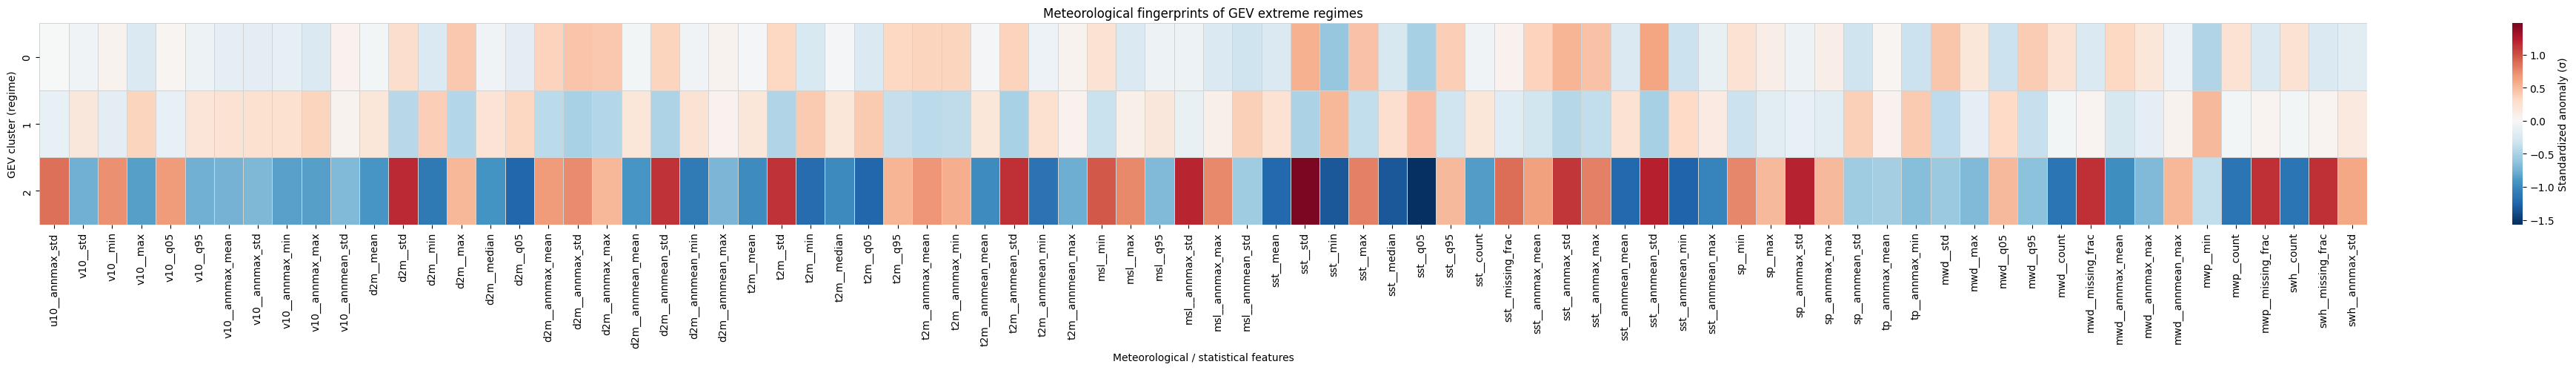

In [32]:
import pandas as pd

# Pull only anomaly columns
anom_cols = [c for c in final_table.columns if c.endswith("_anom_z")]
anom = final_table[anom_cols].copy()
anom.columns = [c.replace("_anom_z", "") for c in anom.columns]

# Optional: keep only variables that show signal
# (removes near-zero, uninformative fields)
anom = anom.loc[:, anom.abs().max(axis=0) > 0.5]
import matplotlib.pyplot as plt
import seaborn as sns  # only for plotting convenience

plt.figure(figsize=(0.45*anom.shape[1] + 4, 0.7*anom.shape[0] + 3))

sns.heatmap(
    anom,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized anomaly (σ)"}
)

plt.ylabel("GEV cluster (regime)")
plt.xlabel("Meteorological / statistical features")
plt.title("Meteorological fingerprints of GEV extreme regimes")
plt.tight_layout()
plt.show()



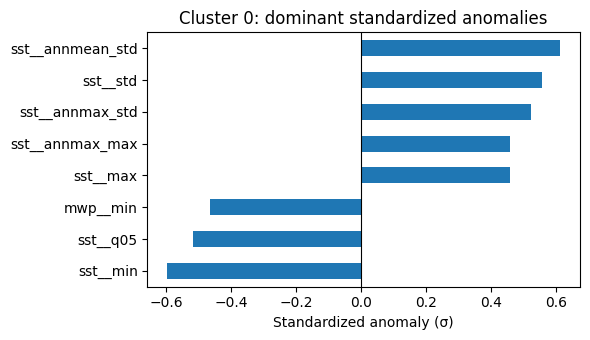

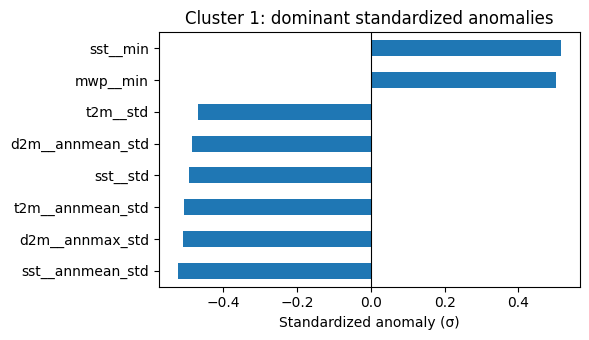

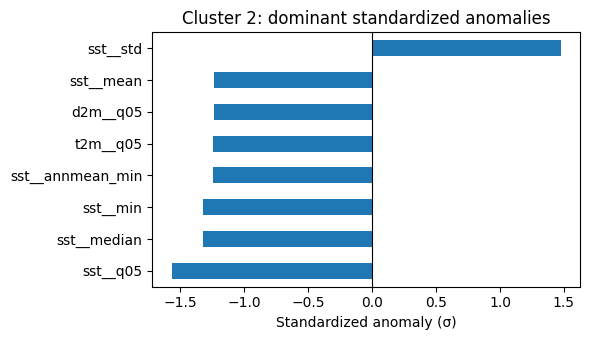

In [33]:
import numpy as np

TOP = 8  # number of variables to show per cluster

for cl in anom.index:
    s = anom.loc[cl].sort_values(key=lambda x: np.abs(x), ascending=False).head(TOP)

    plt.figure(figsize=(6, 3.5))
    s.sort_values().plot(kind="barh")
    plt.axvline(0, color="k", lw=0.8)

    plt.title(f"Cluster {cl}: dominant standardized anomalies")
    plt.xlabel("Standardized anomaly (σ)")
    plt.tight_layout()
    plt.show()


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

Xs_df = pd.DataFrame(Xs, index=X.index, columns=X.columns)
Xs_df["cluster"] = model_df["cluster"].values
centroids_std = Xs_df.groupby("cluster").mean()

print("Centroids in standardized meteorological space:")
display(centroids_std.head())


Centroids in standardized meteorological space:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__count,u10__missing_frac,u10__annmax_mean,...,swh__count,swh__missing_frac,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.088038,-0.112639,0.317473,-0.241859,-0.008614,0.201310,-0.054792,0.0,0.0,-0.084435,...,0.242638,-0.242638,-0.154758,-0.178566,-0.110628,-0.173450,-0.211481,-0.231568,-0.233458,-0.218088
1,-0.090027,0.117593,-0.319369,0.231926,-0.040325,-0.190586,0.082743,0.0,0.0,0.126483,...,-0.040599,0.040599,0.132735,0.143711,0.089661,0.156348,0.209279,0.219712,0.230566,0.213357
2,0.071573,-0.107175,0.223928,-0.096912,0.311195,0.064757,-0.217543,0.0,0.0,-0.328598,...,-1.146688,1.146688,0.399820,0.604346,0.364918,0.333323,0.123972,0.278763,0.143847,0.165106


In [39]:
centroids_phys = pd.DataFrame(
    scaler.inverse_transform(centroids_std),
    index=centroids_std.index,
    columns=X.columns
)

print("Centroids in physical units:")
display(centroids_phys.head())
centroid_spread = centroids_std.max(axis=0) - centroids_std.min(axis=0)
centroid_spread = centroid_spread.sort_values(ascending=False)

print("Variables defining centroid separation:")
print(centroid_spread.head(20))


Centroids in physical units:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__count,u10__missing_frac,u10__annmax_mean,...,swh__count,swh__missing_frac,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.463204,4.679777,-14.611848,21.631088,1.584177,-6.096385,9.026230,750192.0,0.0,16.574150,...,670253.508197,0.106557,4.153114,0.530978,3.147438,5.734162,0.895297,0.061421,0.726518,1.032814
1,1.407061,4.844429,-16.235027,22.924685,1.569321,-6.530076,9.203499,750192.0,0.0,17.011209,...,584590.941176,0.220745,4.598934,0.620878,3.356475,6.503798,1.057370,0.074407,0.875422,1.224151
2,1.458013,4.683684,-14.850274,22.026844,1.733997,-6.247502,8.816459,750192.0,0.0,16.068199,...,250064.000000,0.666667,5.013106,0.749373,3.643754,6.916797,1.024511,0.076106,0.847594,1.202753


Variables defining centroid separation:
sst__q05             2.036037
sst__std             1.965970
sst__min             1.837344
sst__annmean_std     1.745010
t2m__q05             1.656688
t2m__annmean_std     1.656042
t2m__min             1.618875
d2m__annmean_std     1.613595
t2m__std             1.602838
d2m__std             1.600562
sst__median          1.592902
d2m__q05             1.574718
sst__annmax_std      1.573572
sst__annmean_min     1.568359
d2m__min             1.512420
sst__mean            1.482318
sst__annmean_mean    1.481514
t2m__annmean_min     1.420364
mwp__count           1.389327
mwp__missing_frac    1.389327
dtype: float64


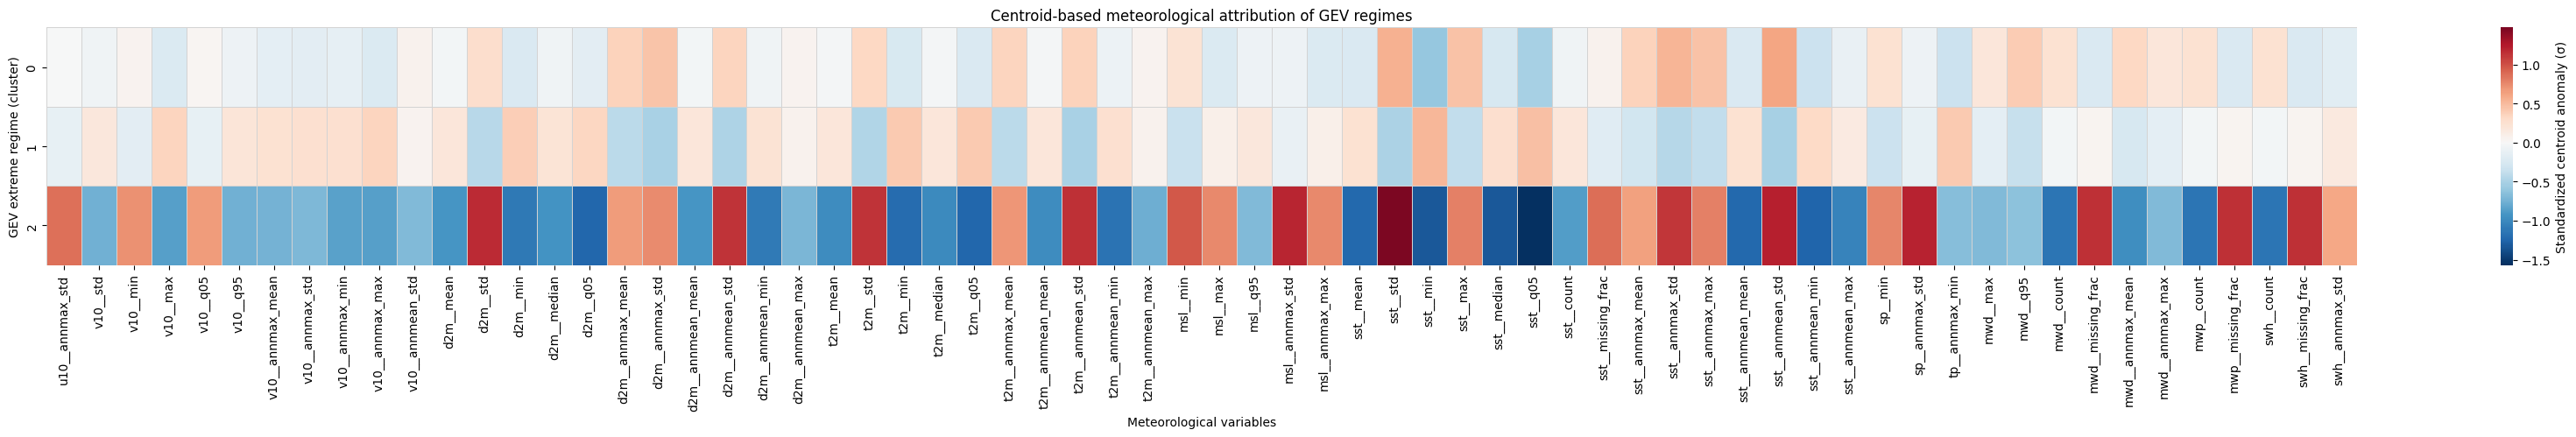

In [41]:
centroid_fingerprint = centroids_std.copy()

# Optional: drop weak signals
centroid_fingerprint = centroid_fingerprint.loc[
    :, centroid_fingerprint.abs().max() > 0.6
]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(0.45*centroid_fingerprint.shape[1] + 4,
                    0.7*centroid_fingerprint.shape[0] + 3))

sns.heatmap(
    centroid_fingerprint,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized centroid anomaly (σ)"}
)

plt.ylabel("GEV extreme regime (cluster)")
plt.xlabel("Meteorological variables")
plt.title("Centroid-based meteorological attribution of GEV regimes")
plt.tight_layout()
plt.show()



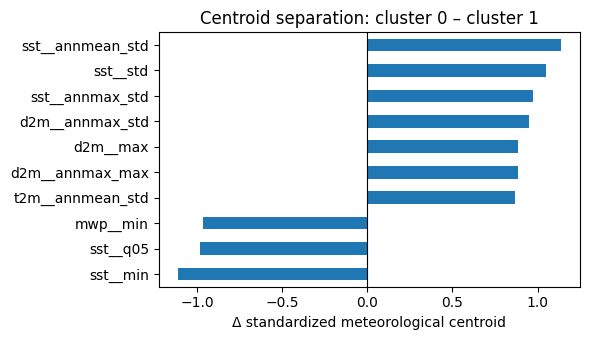

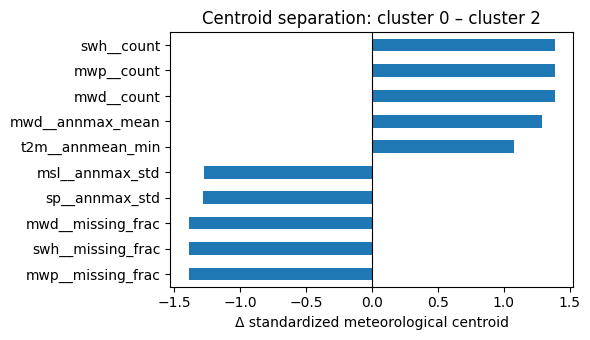

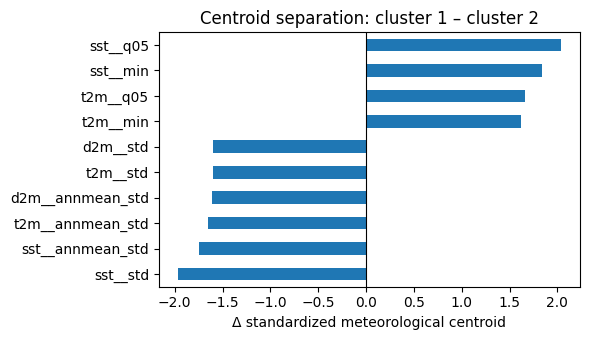

In [42]:
import itertools

for c1, c2 in itertools.combinations(centroids_std.index, 2):
    delta = (centroids_std.loc[c1] - centroids_std.loc[c2]).sort_values(
        key=lambda x: abs(x), ascending=False
    ).head(10)

    plt.figure(figsize=(6, 3.5))
    delta.sort_values().plot(kind="barh")
    plt.axvline(0, color="k", lw=0.8)
    plt.title(f"Centroid separation: cluster {c1} – cluster {c2}")
    plt.xlabel("Δ standardized meteorological centroid")
    plt.tight_layout()
    plt.show()


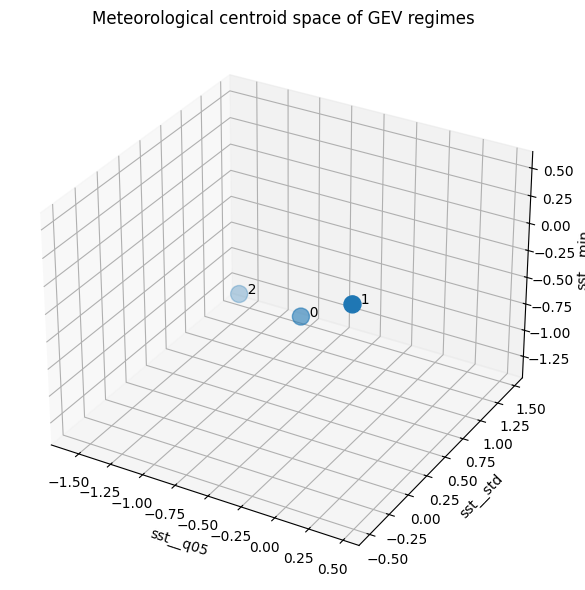

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

# choose three dominant separation variables
top3 = centroid_spread.head(3).index.tolist()
C = centroids_std[top3]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(C[top3[0]], C[top3[1]], C[top3[2]], s=150)

for cl in C.index:
    ax.text(C.loc[cl, top3[0]],
            C.loc[cl, top3[1]],
            C.loc[cl, top3[2]],
            f"  {cl}", fontsize=10)

ax.set_xlabel(top3[0])
ax.set_ylabel(top3[1])
ax.set_zlabel(top3[2])
ax.set_title("Meteorological centroid space of GEV regimes")

plt.tight_layout()
plt.show()


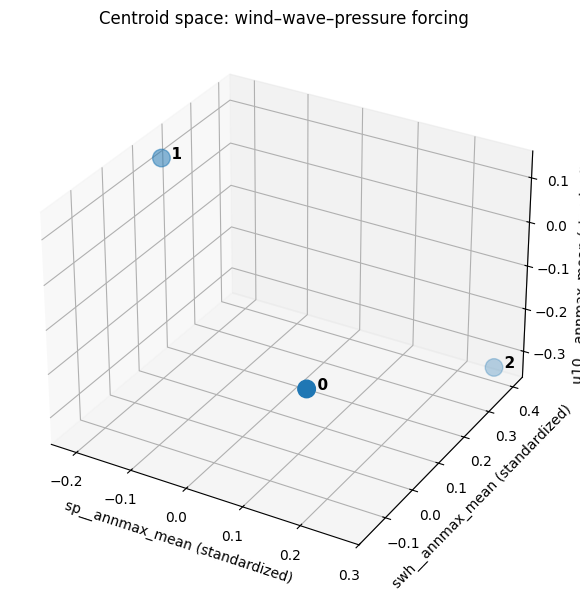

In [59]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.pyplot as plt

def plot_centroid_space(centroids, vars3, title, standardized=True):

    missing = [v for v in vars3 if v not in centroids.columns]
    if missing:
        raise ValueError(f"Missing variables: {missing}")

    C = centroids[vars3]

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(C[vars3[0]], C[vars3[1]], C[vars3[2]], s=160)

    for cl in C.index:
        ax.text(C.loc[cl, vars3[0]],
                C.loc[cl, vars3[1]],
                C.loc[cl, vars3[2]],
                f"  {cl}", fontsize=11, weight="bold")

    lab = " (standardized)" if standardized else ""
    ax.set_xlabel(vars3[0] + lab)
    ax.set_ylabel(vars3[1] + lab)
    ax.set_zlabel(vars3[2] + lab)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_centroid_space(
    centroids_std,
    ['sp__annmax_mean', 'swh__annmax_mean', 'u10__annmax_mean'],
    "Centroid space: wind–wave–pressure forcing",
    standardized=True
)


In [60]:
drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level", "residual", "tide")
forbidden_cols = {c for c in model_df.columns if any(s in c.lower() for s in forbidden_substrings)}

X = model_df.drop(columns=[c for c in (drop_cols | forbidden_cols) if c in model_df.columns])
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

met_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

Xs = met_pre.fit_transform(X)


In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
sil = {}

for k in k_range:
    km_met = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_met = km_met.fit_predict(Xs)
    sil[k] = silhouette_score(Xs, labels_met)

best_k_met = max(sil, key=sil.get)
km_met = KMeans(n_clusters=best_k_met, random_state=0, n_init="auto")
met_cluster = km_met.fit_predict(Xs)

model_df = model_df.copy()
model_df["met_cluster"] = met_cluster

print(model_df["met_cluster"].value_counts())


met_cluster
7    54
2    34
9    31
6    28
0    26
1    26
5    24
4    23
3    19
8    14
Name: count, dtype: int64


In [64]:
centroids_met_std = pd.DataFrame(
    km_met.cluster_centers_,
    columns=X.columns
)


In [65]:
# Recover scaler and imputer from the pipeline
imputer = met_pre.named_steps["imputer"]
scaler  = met_pre.named_steps["scaler"]

# KMeans centers are in standardized space; invert scaling
centroids_met_imputed = scaler.inverse_transform(km_met.cluster_centers_)  # imputed space
centroids_met_phys = pd.DataFrame(centroids_met_imputed, columns=X.columns)

display(centroids_met_phys.head())


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__count,u10__missing_frac,u10__annmax_mean,...,swh__count,swh__missing_frac,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
0,1.573749,4.974489,-17.718657,22.558426,1.722353,-6.742775,9.523161,750192.0,0.0,17.355833,...,548217.230769,0.269231,4.588020,0.656403,3.319100,6.572059,0.923468,0.062780,0.763934,1.092269
1,1.201114,4.367338,-14.416149,20.217264,1.469391,-6.042264,7.987019,750192.0,0.0,14.731980,...,86560.615385,0.884615,4.463565,0.577413,3.184454,5.919796,0.891803,0.059950,0.738111,1.071937
2,1.632383,5.462141,-17.221551,25.202727,1.870986,-7.365917,10.390633,750192.0,0.0,18.668295,...,617805.176471,0.176471,5.532468,0.770789,3.998633,7.872094,1.279981,0.090703,1.067436,1.479048
3,1.497492,4.407042,-15.152372,21.584054,1.619854,-5.789323,8.603043,750192.0,0.0,16.186901,...,750192.000000,0.000000,5.129642,0.803769,3.497741,7.623824,1.111293,0.087784,0.906192,1.298674
4,1.445823,4.446335,-14.096844,21.017258,1.642904,-5.800232,8.575818,750192.0,0.0,15.529778,...,65234.086957,0.913043,4.373260,0.549886,3.127940,5.825171,0.872142,0.058817,0.717792,1.048666


In [66]:
ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")
print(ct)


met_cluster        0         1         2         3         4         5  \
cluster                                                                  
0            0.07377  0.016393  0.040984  0.032787  0.090164  0.155738   
1            0.12500  0.088235  0.213235  0.102941  0.066176  0.007353   
2            0.00000  0.571429  0.000000  0.047619  0.142857  0.190476   

met_cluster         6         7         8         9  
cluster                                              
0            0.172131  0.336066  0.016393  0.065574  
1            0.051471  0.088235  0.088235  0.169118  
2            0.000000  0.047619  0.000000  0.000000  


In [71]:
from scipy.stats import chi2_contingency

ct_counts = pd.crosstab(model_df["cluster"], model_df["met_cluster"])
chi2, p, dof, expected = chi2_contingency(ct_counts)

print("chi2:", chi2, "p-value:", p)


chi2: 158.23011607641374 p-value: 1.8490605416425157e-24


In [72]:
from sklearn.metrics import mutual_info_score

mi = mutual_info_score(model_df["cluster"], model_df["met_cluster"])
print("Mutual information:", mi)


Mutual information: 0.2683991433048924


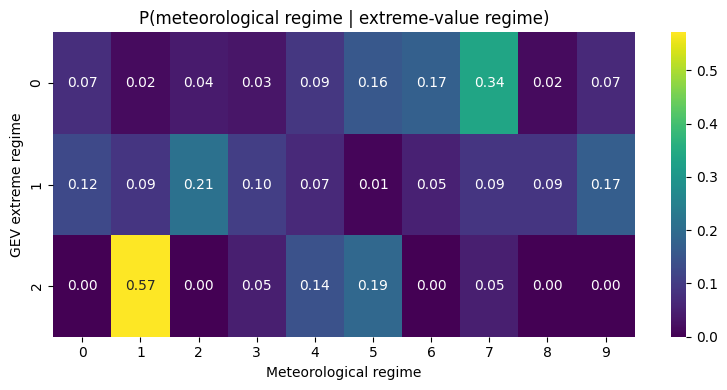

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")

plt.figure(figsize=(8,4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="viridis")

plt.xlabel("Meteorological regime")
plt.ylabel("GEV extreme regime")
plt.title("P(meteorological regime | extreme-value regime)")

plt.tight_layout()
plt.show()


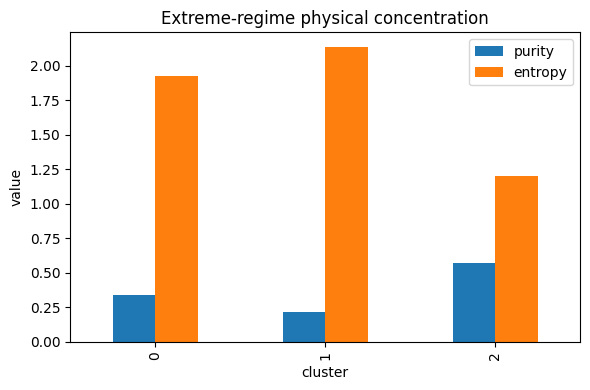

In [75]:
ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")

dominant = ct.idxmax(axis=1)
purity = ct.max(axis=1)
entropy = -(ct * np.log(ct + 1e-12)).sum(axis=1)

summary = pd.DataFrame({
    "dominant_met_regime": dominant,
    "purity": purity,
    "entropy": entropy
})

summary[["purity", "entropy"]].plot(kind="bar", figsize=(6,4))
plt.title("Extreme-regime physical concentration")
plt.ylabel("value")
plt.tight_layout()
plt.show()


Interpretation:

purity → how concentrated the attribution is

entropy → how many meteorological pathways exist

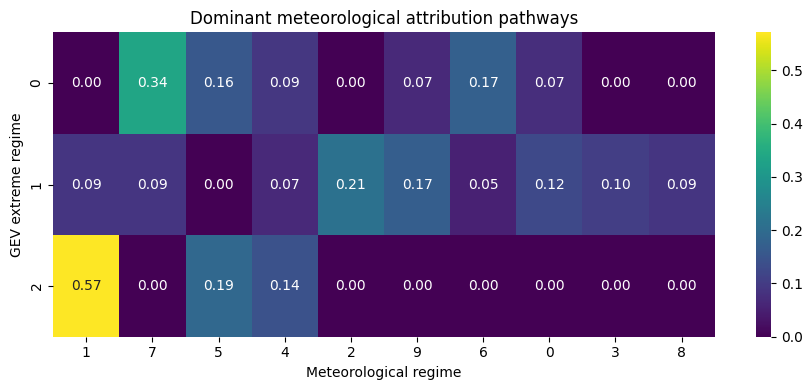

In [76]:
# order columns by overall contribution
order = ct.sum(axis=0).sort_values(ascending=False).index
ct_ord = ct[order]

# zero-out very small probabilities
ct_masked = ct_ord.where(ct_ord > 0.05, 0)

plt.figure(figsize=(9,4))
sns.heatmap(ct_masked, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Meteorological regime")
plt.ylabel("GEV extreme regime")
plt.title("Dominant meteorological attribution pathways")
plt.tight_layout()
plt.show()


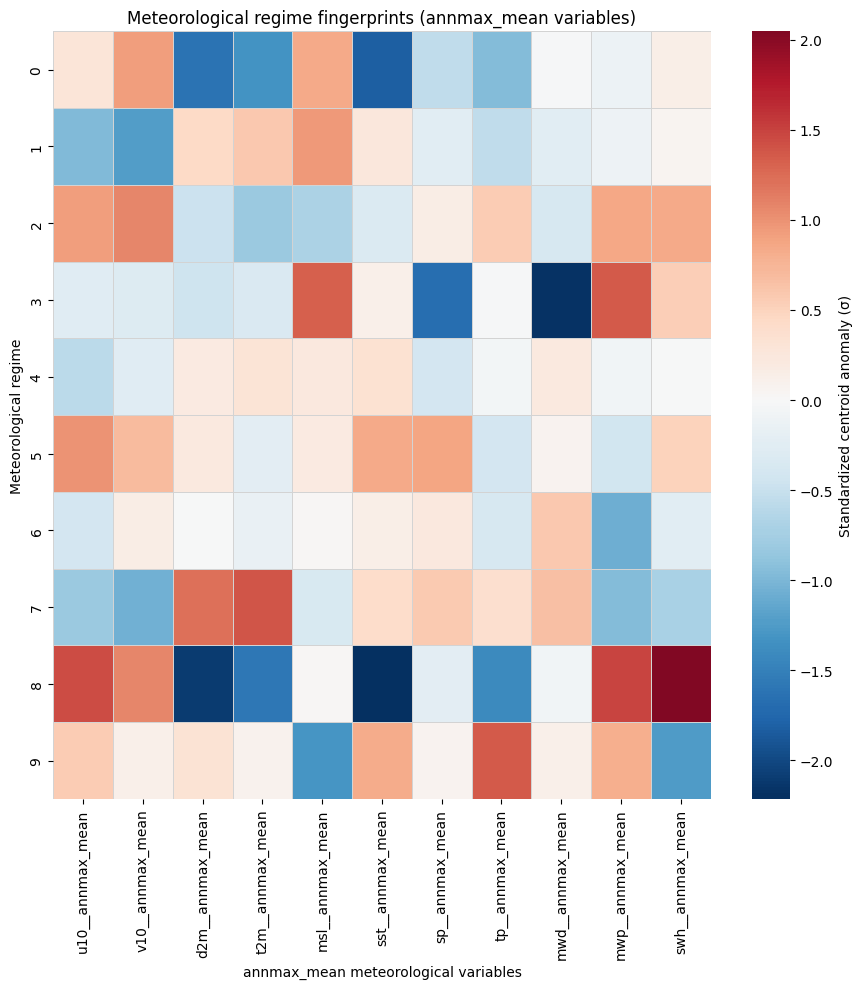

In [82]:
annmax_vars = [c for c in centroids_met_phys.columns if "annmax_mean" in c.lower()]
met_centroids_annmax = centroids_met_phys[annmax_vars].copy()
met_centroids_annmax.index.name = "met_regime"

annmax_std = centroids_met_std[annmax_vars]

# Optional: remove very weak dimensions
annmax_std = annmax_std.loc[:, annmax_std.abs().max(axis=0) > 0.5]

plt.figure(figsize=(0.45*annmax_std.shape[1] + 4,
                    0.7*annmax_std.shape[0] + 3))

sns.heatmap(
    annmax_std,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized centroid anomaly (σ)"}
)

plt.xlabel("annmax_mean meteorological variables")
plt.ylabel("Meteorological regime")
plt.title("Meteorological regime fingerprints (annmax_mean variables)")
plt.tight_layout()
plt.show()


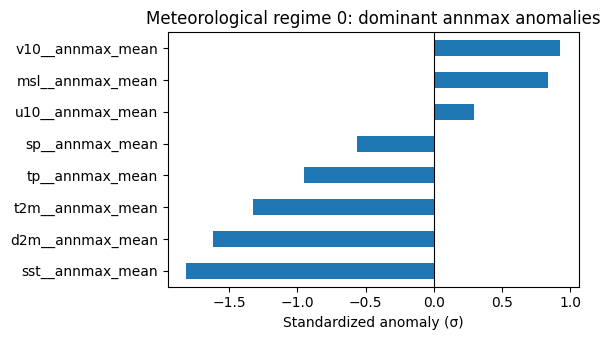

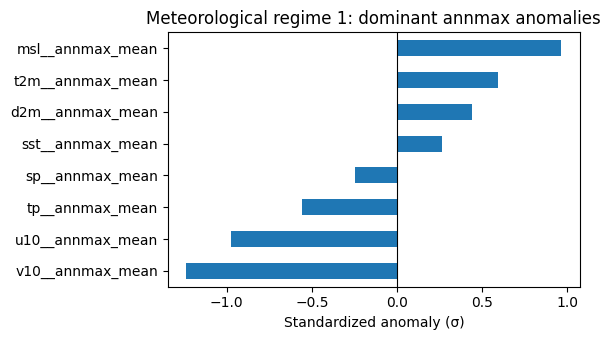

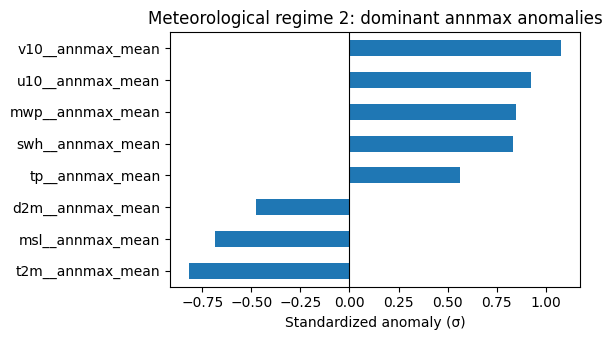

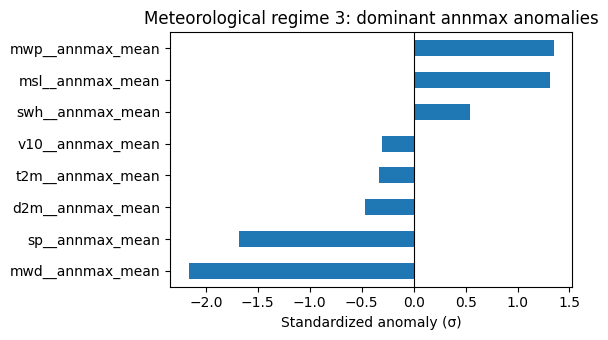

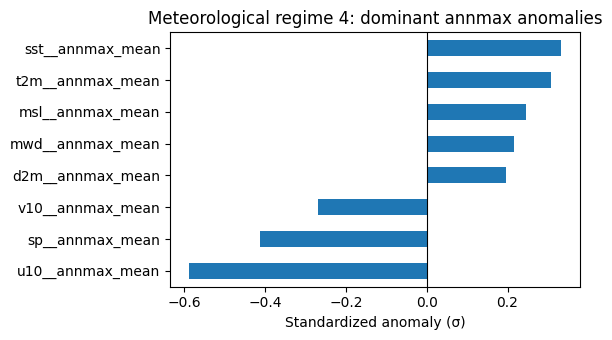

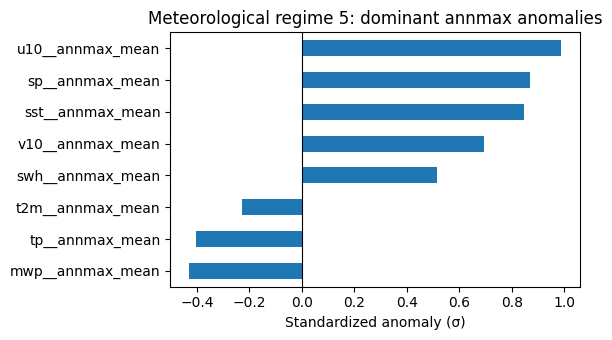

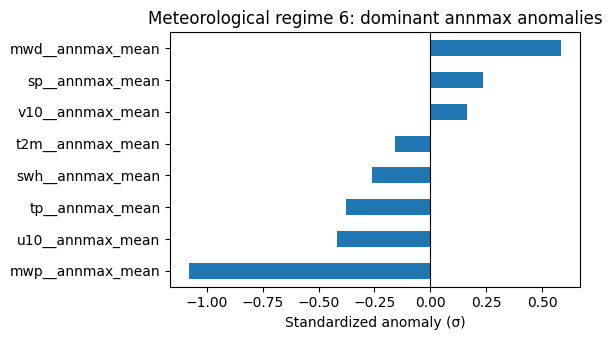

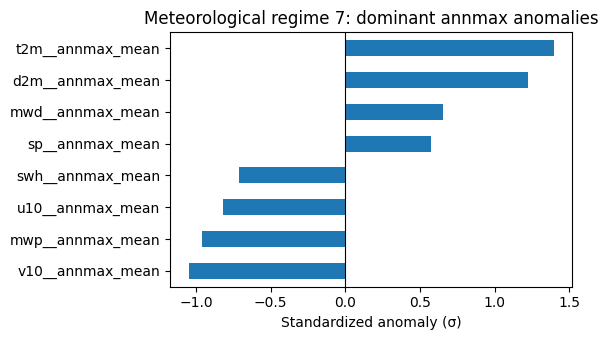

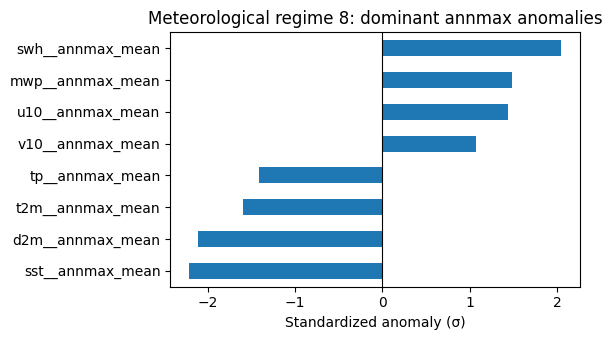

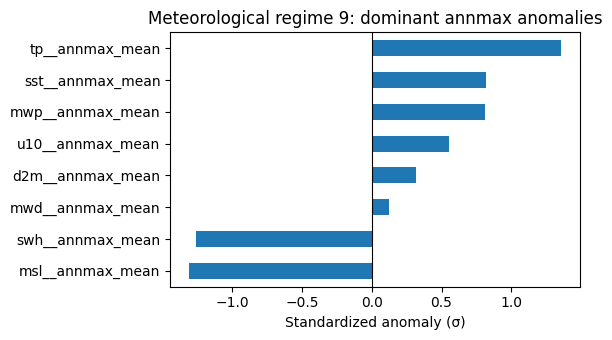

In [83]:
import numpy as np

TOP = 8

for mc in annmax_std.index:
    s = annmax_std.loc[mc].sort_values(key=lambda x: np.abs(x), ascending=False).head(TOP)

    plt.figure(figsize=(6,3.5))
    s.sort_values().plot(kind="barh")
    plt.axvline(0, color="k", lw=0.8)

    plt.title(f"Meteorological regime {mc}: dominant annmax anomalies")
    plt.xlabel("Standardized anomaly (σ)")
    plt.tight_layout()
    plt.show()


Dominant meteorological regimes: [1, 2, 7]


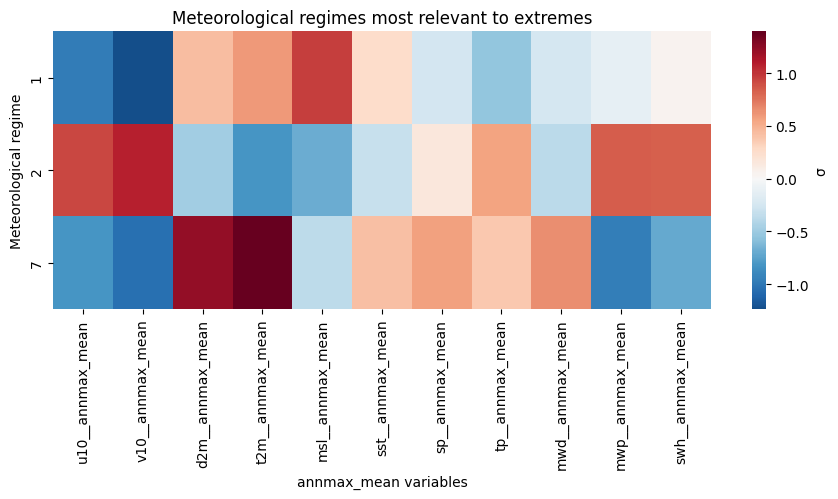

In [85]:
# meteorological regimes that dominate any extreme regime
dominant_mets = set(ct.idxmax(axis=1))
dominant_mets = sorted(dominant_mets)

print("Dominant meteorological regimes:", dominant_mets)

annmax_dom = annmax_std.loc[dominant_mets]

plt.figure(figsize=(0.45*annmax_dom.shape[1] + 4,
                    0.7*annmax_dom.shape[0] + 3))

sns.heatmap(annmax_dom, center=0, cmap="RdBu_r",
            cbar_kws={"label": "σ"})
plt.title("Meteorological regimes most relevant to extremes")
plt.xlabel("annmax_mean variables")
plt.ylabel("Meteorological regime")
plt.tight_layout()
plt.show()


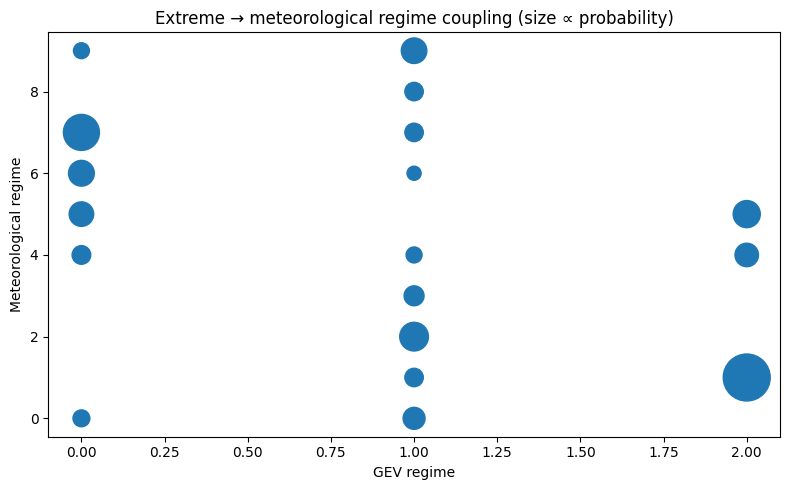

In [77]:
import matplotlib.pyplot as plt

flows = ct.stack().reset_index()
flows.columns = ["gev", "met", "p"]
flows = flows[flows["p"] > 0.05]  # keep only meaningful links

plt.figure(figsize=(8,5))
plt.scatter(flows["gev"], flows["met"], s=flows["p"]*2000)
plt.xlabel("GEV regime")
plt.ylabel("Meteorological regime")
plt.title("Extreme → meteorological regime coupling (size ∝ probability)")
plt.tight_layout()
plt.show()


In [67]:
ct2 = pd.crosstab(model_df["met_cluster"], model_df["cluster"], normalize="index")
print(ct2)


cluster             0         1         2
met_cluster                              
0            0.346154  0.653846  0.000000
1            0.076923  0.461538  0.461538
2            0.147059  0.852941  0.000000
3            0.210526  0.736842  0.052632
4            0.478261  0.391304  0.130435
5            0.791667  0.041667  0.166667
6            0.750000  0.250000  0.000000
7            0.759259  0.222222  0.018519
8            0.142857  0.857143  0.000000
9            0.258065  0.741935  0.000000


In [68]:
# For each meteorological cluster, list the strongest centroid anomalies (standardized)
centroids_met_std = pd.DataFrame(km_met.cluster_centers_, columns=X.columns)
spread = centroids_met_std.abs().max(axis=0)

# For each meteorological cluster, print top defining variables
TOP = 10
for mc in range(best_k_met):
    s = centroids_met_std.loc[mc].sort_values(key=lambda x: abs(x), ascending=False).head(TOP)
    print(f"\nMeteorological cluster {mc} top centroid components:")
    print(s)



Meteorological cluster 0 top centroid components:
sst__q95           -1.820579
sst__annmax_mean   -1.814936
sst__annmax_min    -1.781586
d2m__annmax_min    -1.682370
sst__annmax_max    -1.657649
sst__max           -1.657649
v10__annmean_max    1.656703
t2m__q95           -1.621361
d2m__annmax_mean   -1.616575
d2m__q95           -1.615778
Name: 0, dtype: float64

Meteorological cluster 1 top centroid components:
d2m__q05            -1.965132
d2m__annmean_min    -1.811776
t2m__annmean_min    -1.779794
msl__annmax_std      1.766056
sp__annmax_std       1.751424
t2m__q05            -1.721811
d2m__mean           -1.699212
d2m__annmean_mean   -1.698709
mwd__missing_frac    1.687301
mwp__missing_frac    1.687301
Name: 1, dtype: float64

Meteorological cluster 2 top centroid components:
t2m__q05             1.384273
d2m__annmean_min     1.366773
d2m__median          1.357846
t2m__annmean_min     1.331662
d2m__annmean_mean    1.323122
d2m__mean            1.322582
t2m__mean            1.276803

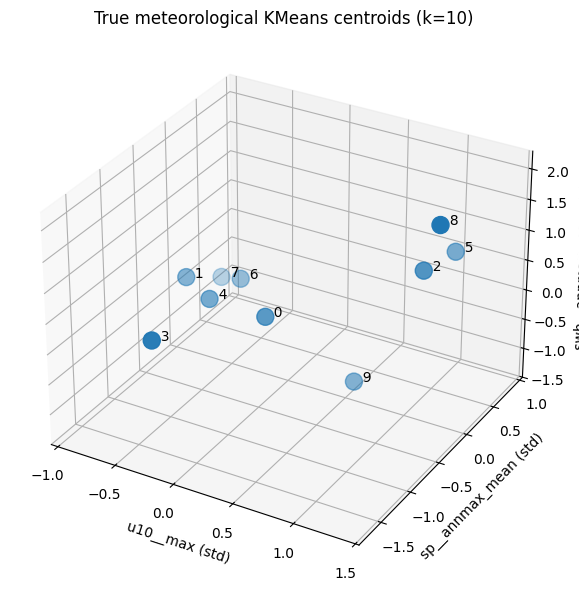

In [70]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.pyplot as plt

vars3 = ["u10__max", "sp__annmax_mean", "swh__annmax_mean"]  # use names that exist in X

C = centroids_met_std[vars3]  # true met centroids in standardized space

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(C[vars3[0]], C[vars3[1]], C[vars3[2]], s=150)

for mc in C.index:
    ax.text(C.loc[mc, vars3[0]], C.loc[mc, vars3[1]], C.loc[mc, vars3[2]], f"  {mc}", fontsize=10)

ax.set_xlabel(vars3[0] + " (std)")
ax.set_ylabel(vars3[1] + " (std)")
ax.set_zlabel(vars3[2] + " (std)")
ax.set_title(f"True meteorological KMeans centroids (k={best_k_met})")

plt.tight_layout()
plt.show()
